# UFC Pipeline — Scraping, ML & Ranking

**One notebook for everything:** incremental scraping, data update, feature engineering, ML models and ranking by division.

---
## Section 0 — Configuration

Edit the values below before running the notebook.

In [1]:
# ─── CONFIGURABLE PARAMETERS ──────────────────────────────────────────────

# Weights for the weighted ranking (must sum to 1.0)
WEIGHTS = {
    'win_rate':        0.20,
    'finish_rate':     0.15,
    'sig_str_per_min': 0.15,
    'sig_str_acc':     0.10,
    'td_per_min':      0.10,
    'td_acc':          0.10,
    'ctrl_per_min':    0.10,
    'kd_per_min':      0.05,
    'sub_att_per_min': 0.05,
}

# Filter by division (None = all divisions)
# Examples: 'Lightweight', 'Heavyweight', 'Middleweight'
WEIGHT_CLASS_FILTER = None

# Minimum number of UFC fights to appear in the ranking
MIN_FIGHTS_RANKING = 5

# ─── SETUP ────────────────────────────────────────────────────────────────
import sys, os
# Add project root to path for imports
PROJECT_ROOT = os.path.abspath('')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

STATE_FILE = os.path.join(PROJECT_ROOT, 'data', 'state', 'last_run.json')
MASTER_CSV = os.path.join(PROJECT_ROOT, 'data', 'processed', 'ufc_master_enriched.csv')

# Read last run state
with open(STATE_FILE, 'r') as f:
    state = json.load(f)

print('Configuration loaded')
print(f'Last run: {state["last_run"] or "never (first run)"}')
print(f'Total known fights: {state["n_fights_total"]}')
print(f'Division filter: {WEIGHT_CLASS_FILTER or "all"}')
print(f'Min fights for ranking: {MIN_FIGHTS_RANKING}')

Configuration loaded
Last run: 2026-03-03
Total known fights: 8666
Division filter: all
Min fights for ranking: 5


---
## Section 1 — Data Update

1. Incremental scraping of ufcstats.com
2. Re-download of Kaggle datasets
3. Merge and deduplication -> master CSV
4. State file update

In [2]:
import io, contextlib
from datetime import date
from src.ingest.ingest_data import scrape_since
from src.processing.update_master import update

# Convert last_run to date if not null
last_date = None
if state['last_run']:
    from datetime import datetime
    last_date = datetime.strptime(state['last_run'], '%Y-%m-%d').date()

print('=' * 60)
if last_date:
    print(f'INCREMENTAL run — scraping fights after {last_date}')
else:
    print('FIRST RUN — scraping all fights')
print('=' * 60)

# 1. Scraping ufcstats (incremental: only new fights)
#    New fights -> ufc_scraped_recent.csv -> appended to ufc_scraped_data.csv -> recent cleared
print('[1/2] Scraping ufcstats.com...')
with contextlib.redirect_stdout(io.StringIO()):
    df_scraped, n_scraped = scrape_since(last_date=last_date)
print(f'  Scraped fights: {n_scraped}')

# 2. Rebuild master from ALL sources (Kaggle 1 + Kaggle 2 + ufc_scraped_data.csv)
#    This is fast (CSV operations only), no need for incremental merge
print('[2/2] Rebuilding master CSV from all sources...')
n_before = state['n_fights_total']
with contextlib.redirect_stdout(io.StringIO()):
    df_master, n_total = update()
n_new = max(n_total - n_before, 0)
print(f'  New fights integrated: {n_new}')
print(f'  Total master: {n_total} fights')

INCREMENTAL run — scraping fights after 2026-03-03
[1/2] Scraping ufcstats.com...
  Scraped fights: 0
[2/2] Rebuilding master CSV from all sources...
  New fights integrated: 0
  Total master: 8666 fights


In [3]:
# Update state file
today_str = date.today().isoformat()
state['last_run'] = today_str
state['n_fights_total'] = len(df_master)
os.makedirs(os.path.dirname(STATE_FILE), exist_ok=True)
with open(STATE_FILE, 'w') as f:
    json.dump(state, f, indent=2)

print(f'State updated: last_run = {today_str}')
print(f'Total fights in database: {len(df_master)}')

State updated: last_run = 2026-03-04
Total fights in database: 8666


---
## Section 2 — Dataset Overview

Master CSV structure, global statistics, distributions.

In [4]:
df = pd.read_csv(MASTER_CSV)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Period: {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Unique fighters: {pd.concat([df["R_Fighter"], df["B_Fighter"]]).nunique()}')
print(f'Red win rate: {df["R_Win"].mean()*100:.1f}%')

# Available columns
print(f'\nColumns ({len(df.columns)}):')
print(', '.join(df.columns.tolist()))

Shape: (8666, 114)
Period: 1994-03-11 -> 2026-02-28
Unique fighters: 2682
Red win rate: 63.1%

Columns (114):
R_Fighter, B_Fighter, R_KD, B_KD, R_SIG_STR_pct, B_SIG_STR_pct, R_TD_pct, B_TD_pct, R_SUB_ATT, B_SUB_ATT, R_REV, B_REV, win_by, last_round, last_round_time, Format, Referee, date, location, Fight_type, Winner, R_SIG_STR_landed, R_SIG_STR_attempted, R_TOTAL_STR_landed, R_TOTAL_STR_attempted, R_TD_landed, R_TD_attempted, R_HEAD_landed, R_HEAD_attempted, R_BODY_landed, R_BODY_attempted, R_LEG_landed, R_LEG_attempted, R_DISTANCE_landed, R_DISTANCE_attempted, R_CLINCH_landed, R_CLINCH_attempted, R_GROUND_landed, R_GROUND_attempted, R_CTRL_sec, B_SIG_STR_landed, B_SIG_STR_attempted, B_TOTAL_STR_landed, B_TOTAL_STR_attempted, B_TD_landed, B_TD_attempted, B_HEAD_landed, B_HEAD_attempted, B_BODY_landed, B_BODY_attempted, B_LEG_landed, B_LEG_attempted, B_DISTANCE_landed, B_DISTANCE_attempted, B_CLINCH_landed, B_CLINCH_attempted, B_GROUND_landed, B_GROUND_attempted, B_CTRL_sec, R_Win, B_W

In [5]:
# 5 most recent fights
display_cols = [c for c in ['date','R_Fighter','B_Fighter','WeightClass',
                             'win_by','last_round','R_Win'] if c in df.columns]
print('5 most recent fights:')
df[display_cols].tail(5)

5 most recent fights:


,date,R_Fighter,B_Fighter,WeightClass,win_by,last_round,R_Win
8661,2026-02-28,Erik Silva,Francis Marshall,NaN,NaN,1,0
8662,2026-02-28,Imanol Rodriguez,Kevin Borjas,NaN,NaN,2,1
8663,2026-02-28,Regina Tarin,Ernesta Kareckaite,NaN,NaN,3,1
8664,2026-02-28,Marlon Vera,David Martinez,NaN,NaN,3,0
8665,2026-02-28,Douglas Silva de Andrade,Javier Reyes,NaN,NaN,1,0


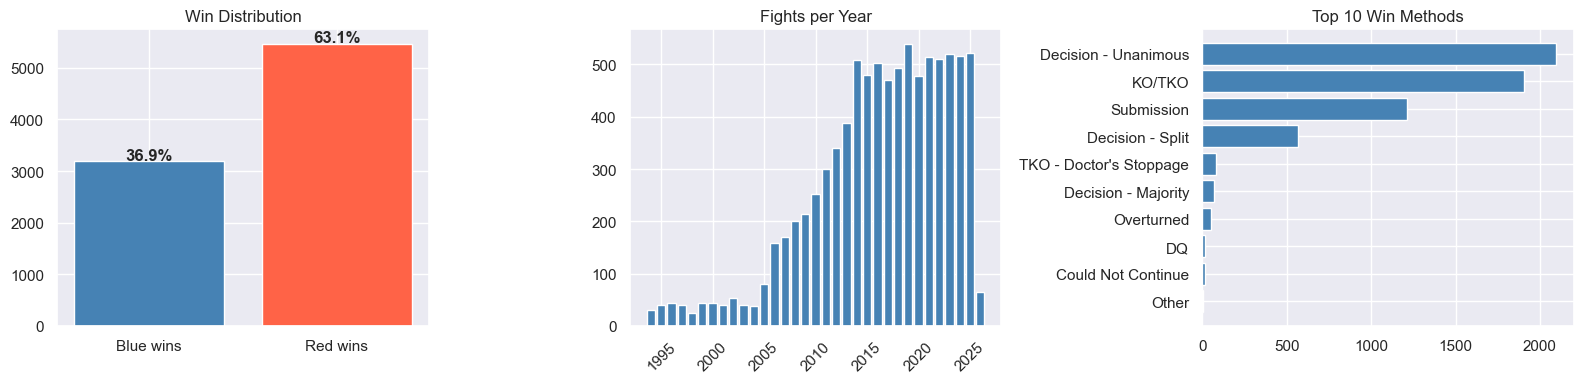

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Win distribution
win_counts = df['R_Win'].value_counts()
axes[0].bar(['Blue wins', 'Red wins'],
            [win_counts.get(0, 0), win_counts.get(1, 0)],
            color=['steelblue', 'tomato'])
axes[0].set_title('Win Distribution')
for i, v in enumerate([win_counts.get(0, 0), win_counts.get(1, 0)]):
    axes[0].text(i, v + 20, f'{v/len(df)*100:.1f}%', ha='center', fontweight='bold')

# Fights per year
df['year'] = df['date'].dt.year
yearly = df.groupby('year').size()
axes[1].bar(yearly.index, yearly.values, color='steelblue', edgecolor='white')
axes[1].set_title('Fights per Year')
axes[1].tick_params(axis='x', rotation=45)

# Win methods
method_col = 'win_by' if 'win_by' in df.columns else 'method'
if method_col in df.columns:
    methods = df[method_col].value_counts().head(10)
    axes[2].barh(methods.index[::-1], methods.values[::-1], color='steelblue')
    axes[2].set_title('Top 10 Win Methods')

plt.tight_layout()
plt.show()

---
## Section 3 — Feature Engineering

Vectorization without data leakage via `expanding().mean().shift(1)` per fighter.

For a fight at date T, each feature = cumulative statistic from fights **before T**.

In [7]:
from src.processing.feature_engineering import build_features, get_feature_cols

print('Building features (may take 30-60 seconds)...')
features_df = build_features(df)

feat_cols = get_feature_cols(features_df, include_odds=True)
feat_cols_no_odds = get_feature_cols(features_df, include_odds=False)

print(f'Features shape: {features_df.shape}')
print(f'Nb features (with odds): {len(feat_cols)}')
print(f'Nb features (without odds): {len(feat_cols_no_odds)}')
print(f'Target R_Win: {features_df["R_Win"].mean()*100:.1f}% Red')

Building features (may take 30-60 seconds)...
Features shape: (6810, 44)
Nb features (with odds): 37
Nb features (without odds): 35
Target R_Win: 61.7% Red


In [8]:
# Missing values per feature
null_pct = features_df[feat_cols].isnull().mean() * 100
null_pct = null_pct.sort_values(ascending=False)

print('Missing values per feature:')
for col, pct in null_pct.items():
    if pct > 0:
        print(f'  {col:45s}  {pct:.1f}%')
print(f'\n{(null_pct == 0).sum()} features with no missing values')

Missing values per feature:
  delta_implied_prob                             28.9%
  R_implied_prob                                 28.8%
  delta_reach                                    25.5%
  delta_age                                      18.2%
  delta_height                                   15.9%
  B_age                                          13.5%
  R_age                                          9.3%
  delta_recent3_KD_pm                            0.2%
  delta_avg_SUB_ATT_pm                           0.2%
  delta_avg_KD_pm                                0.2%

27 features with no missing values


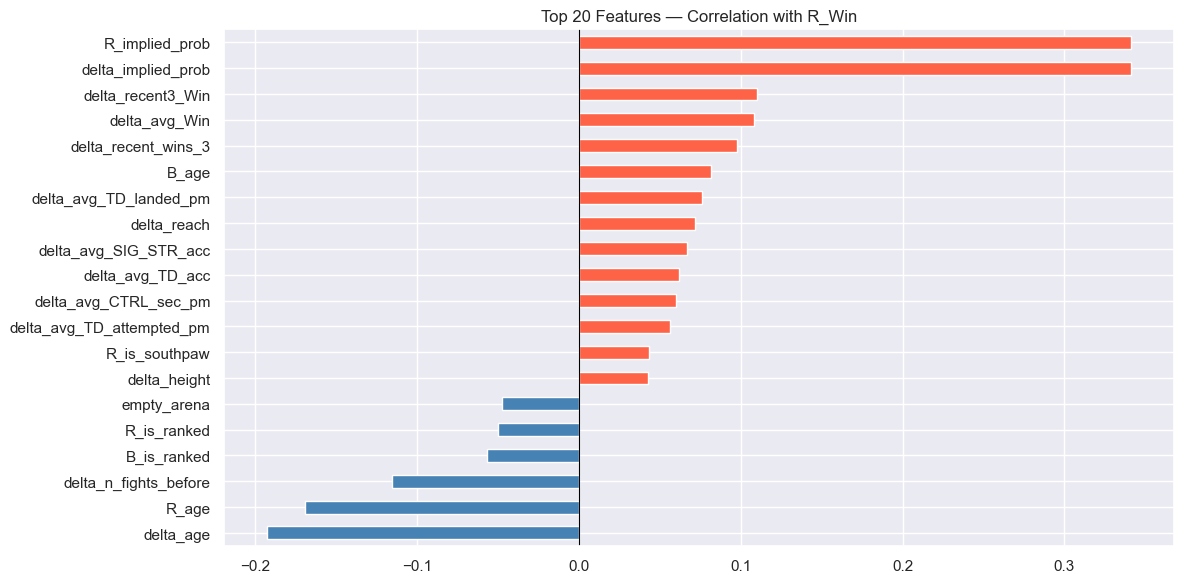

Most predictive feature: R_implied_prob  (|r| = 0.341)


In [9]:
# Top 20 features by correlation with R_Win
num_feats = [c for c in feat_cols if features_df[c].dtype in ['float64', 'float32', 'int64']]
corr = features_df[num_feats + ['R_Win']].corr()['R_Win'].drop('R_Win')
top_corr = corr.abs().sort_values(ascending=False).head(20)
vals = corr[top_corr.index].sort_values()

plt.figure(figsize=(12, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in vals]
vals.plot(kind='barh', color=colors)
plt.title('Top 20 Features — Correlation with R_Win')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print(f'Most predictive feature: {top_corr.index[0]}  (|r| = {top_corr.iloc[0]:.3f})')

---
## Section 4 — ML Models

Temporal split 70/15/15 + Logistic Regression, SVM, Random Forest, XGBoost.

**Strict rule:** preprocessing (imputation + scaling) fitted only on the training set.

In [10]:
from src.models.ranking import (
    temporal_split, make_preprocessor, train_models,
    compare_models, compute_elo, elo_ranking,
    build_fighter_current_stats, rank_by_weights, rank_by_model,
    compare_with_official,
)

train, val, test = temporal_split(features_df)

X_tr  = train[feat_cols].values;  y_tr  = train['R_Win'].values
X_val = val[feat_cols].values;    y_val = val['R_Win'].values
X_te  = test[feat_cols].values;   y_te  = test['R_Win'].values

# Preprocessing (fit ONLY on train)
preproc = make_preprocessor()
X_tr_p  = preproc.fit_transform(X_tr)
X_val_p = preproc.transform(X_val)
X_te_p  = preproc.transform(X_te)

print(f'Train: {len(train):5d} fights  ({train["date"].min().date()} -> {train["date"].max().date()})')
print(f'Val:   {len(val):5d} fights  ({val["date"].min().date()} -> {val["date"].max().date()})')
print(f'Test:  {len(test):5d} fights  ({test["date"].min().date()} -> {test["date"].max().date()})')

Train:  4767 fights  (1994-03-11 -> 2021-04-24)
Val:    1021 fights  (2021-04-24 -> 2023-09-16)
Test:   1022 fights  (2023-09-16 -> 2026-02-28)


In [11]:
# Baseline: betting odds
if 'R_implied_prob' in features_df.columns:
    test_odds = test[test['R_implied_prob'].notna()].copy()
    if len(test_odds) > 10:
        from sklearn.metrics import accuracy_score, roc_auc_score
        pred_odds = (test_odds['R_implied_prob'] > 0.5).astype(int)
        acc = accuracy_score(test_odds['R_Win'], pred_odds)
        auc = roc_auc_score(test_odds['R_Win'], test_odds['R_implied_prob'])
        print(f'Odds Baseline — Accuracy: {acc*100:.1f}%  |  AUC: {auc:.3f}')
        print('The ML model must beat these values.')
else:
    print('No odds available for this dataset.')

Odds Baseline — Accuracy: 68.9%  |  AUC: 0.734
The ML model must beat these values.


In [12]:
print('Training models...')
models = train_models(X_tr_p, y_tr, X_val_p, y_val, feat_cols=feat_cols)

Training models...
  [1/4] Logistic Regression...
    LR best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}  |  Val AUC: 0.692
  [2/4] SVM...
    SVM best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}  |  Val AUC: 0.690
  [3/4] Random Forest...
    RF best params: {'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 300}  |  Val AUC: 0.671
  [4/4] XGBoost...
[0]	train-auc:0.74632	train-logloss:0.64016	val-auc:0.65148	val-logloss:0.70027
[99]	train-auc:0.84756	train-logloss:0.48378	val-auc:0.66396	val-logloss:0.64954
    XGB best round: 69  |  Val AUC: 0.664


In [13]:
# Comparison table
results_df, probas = compare_models(models, X_te_p, y_te, X_val_p, y_val, feat_cols=feat_cols)
print('\n=== Model Comparison ===')
print(results_df.to_string(index=False))


=== Model Comparison ===
       Model Val_Acc Val_AUC Test_Acc Test_AUC Test_Brier
      LogReg   63.3%   0.692    58.9%    0.651      0.244
         SVM   63.1%   0.690    59.1%    0.638      0.254
RandomForest   65.1%   0.671    58.6%    0.609      0.262
     XGBoost   64.1%   0.664    58.9%    0.611      0.263


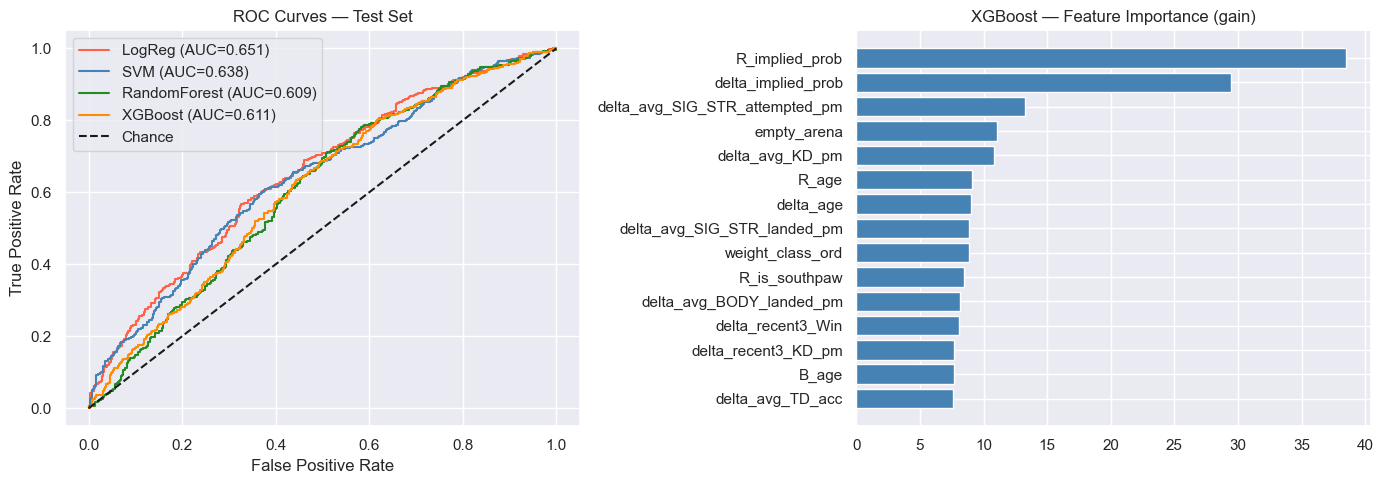

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
colors = ['tomato', 'steelblue', 'forestgreen', 'darkorange']
for (name, proba), col in zip(probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=col)
axes[0].plot([0, 1], [0, 1], 'k--', label='Chance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Test Set')
axes[0].legend()

# Feature importance XGBoost
if 'XGBoost' in models and isinstance(models['XGBoost'], dict):
    import xgboost as xgb
    booster = models['XGBoost']['booster']
    imp = booster.get_score(importance_type='gain')
    imp_df = pd.DataFrame(imp.items(), columns=['Feature', 'Importance'])
    imp_df = imp_df.sort_values('Importance', ascending=True).tail(15)
    axes[1].barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
    axes[1].set_title('XGBoost — Feature Importance (gain)')
elif 'RandomForest' in models:
    rf = models['RandomForest']
    imp_df = pd.DataFrame({'Feature': feat_cols, 'Importance': rf.feature_importances_})
    imp_df = imp_df.sort_values('Importance', ascending=True).tail(15)
    axes[1].barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
    axes[1].set_title('Random Forest — Feature Importance')

plt.tight_layout()
plt.show()

---
## Section 5 — UFC Ranking

Three ranking methods:
1. **Weighted Ranking** — based on weights defined in Section 0
2. **ML Round-Robin Ranking** — `P(A beats B)` for all pairs
3. **Dynamic Elo** — historical skill level per fighter

Final comparison with official UFC rankings (Spearman/Kendall).

In [15]:
# Current profile for each fighter
fighter_stats = build_fighter_current_stats(df)
print(f'Fighters with stats: {len(fighter_stats)}')
print(f'Fighters with >= {MIN_FIGHTS_RANKING} fights: {(fighter_stats["n_fights"] >= MIN_FIGHTS_RANKING).sum()}')

Fighters with stats: 2682
Fighters with >= 5 fights: 1250


In [16]:
# ─── 1. Weighted Ranking ─────────────────────────────────────────────
print('=== WEIGHTED RANKING ===')
if WEIGHT_CLASS_FILTER:
    print(f'Division: {WEIGHT_CLASS_FILTER}')
    w_rank = rank_by_weights(fighter_stats, WEIGHTS, WEIGHT_CLASS_FILTER, MIN_FIGHTS_RANKING)
    print(w_rank.head(15).to_string(index=False))
else:
    divisions = ['Heavyweight', 'Light Heavyweight', 'Middleweight', 'Welterweight',
                 'Lightweight', 'Featherweight', 'Bantamweight', 'Flyweight']
    divisions = [d for d in divisions if d in fighter_stats.get('WeightClass', pd.Series()).values]
    if not divisions:
        # All divisions combined
        w_rank = rank_by_weights(fighter_stats, WEIGHTS, None, MIN_FIGHTS_RANKING)
        print('Global Top 20:')
        print(w_rank.head(20).to_string(index=False))
    else:
        for div in divisions[:4]:  # Show first 4
            w_rank = rank_by_weights(fighter_stats, WEIGHTS, div, MIN_FIGHTS_RANKING)
            if len(w_rank) > 0:
                print(f'\n{div.upper()} (Top 10):')
                print(w_rank.head(10).to_string(index=False))

=== WEIGHTED RANKING ===

HEAVYWEIGHT (Top 10):
 Rank               Fighter  Score  n_fights       WeightClass
    1       Jailton Almeida 0.5479        11       Heavyweight
    2             Jon Jones 0.5105        24 Light Heavyweight
    3        Corey Anderson 0.5072        15 Light Heavyweight
    4          Tom Aspinall 0.4987        10       Heavyweight
    5        Cain Velasquez 0.4873        15       Heavyweight
    6 Gadzhimurad Antigulov 0.4647         6 Light Heavyweight
    7        Daniel Cormier 0.4612        15 Light Heavyweight
    8           Soa Palelei 0.4492         7       Heavyweight
    9         Valter Walker 0.4437         5       Heavyweight
   10          Stipe Miocic 0.4378        19       Heavyweight

LIGHT HEAVYWEIGHT (Top 10):
 Rank               Fighter  Score  n_fights       WeightClass
    1             Jon Jones 0.5472        24 Light Heavyweight
    2        Corey Anderson 0.5449        15 Light Heavyweight
    3 Gadzhimurad Antigulov 0.4989       

In [17]:
# ─── 2. ML Round-Robin Ranking ──────────────────────────────────────
# Use the best model (without odds for market independence)
print('=== ML RANKING (ROUND-ROBIN) ===')

# Preprocessing without odds
X_tr_no = train[feat_cols_no_odds].values
X_val_no = val[feat_cols_no_odds].values

preproc_no = make_preprocessor()
X_tr_no_p = preproc_no.fit_transform(X_tr_no)

# Use Logistic Regression (faster for round-robin)
best_model_name = results_df.sort_values('Test_AUC', ascending=False).iloc[0]['Model']
print(f'Best model: {best_model_name}')

# For round-robin, use LR without odds
from sklearn.linear_model import LogisticRegression
lr_no = LogisticRegression(max_iter=1000, C=1, solver='liblinear', random_state=42)
lr_no.fit(X_tr_no_p, y_tr)

if WEIGHT_CLASS_FILTER:
    ml_rank = rank_by_model(fighter_stats, lr_no, preproc_no, feat_cols_no_odds,
                             WEIGHT_CLASS_FILTER, MIN_FIGHTS_RANKING)
    print(f'Division: {WEIGHT_CLASS_FILTER}')
    print(ml_rank.head(15).to_string(index=False))
else:
    for div in (['Lightweight', 'Heavyweight', 'Middleweight', 'Welterweight'][:3]):
        ml_rank = rank_by_model(fighter_stats, lr_no, preproc_no, feat_cols_no_odds,
                                 div, MIN_FIGHTS_RANKING)
        if len(ml_rank) > 0:
            print(f'\n{div.upper()} (Top 10):')
            print(ml_rank.head(10).to_string(index=False))

=== ML RANKING (ROUND-ROBIN) ===
Best model: LogReg

LIGHTWEIGHT (Top 10):
 Rank             Fighter  Score WeightClass
    1    Gregor Gillespie 112.75 Lightweight
    2 Khabib Nurmagomedov 111.97 Lightweight
    3   Terrance McKinney 109.47 Lightweight
    4     Michel Prazeres 107.78 Lightweight
    5      Sage Northcutt 107.67 Lightweight
    6     Rustam Khabilov 106.39 Lightweight
    7         Mark Madsen 105.93 Lightweight
    8       Manuel Torres 105.72 Lightweight
    9     Islam Makhachev 104.01 Lightweight
   10          Sean Sherk 103.73 Lightweight

HEAVYWEIGHT (Top 10):
 Rank         Fighter  Score       WeightClass
    1  Corey Anderson  96.88 Light Heavyweight
    2       Jon Jones  93.71 Light Heavyweight
    3    Tom Aspinall  93.64       Heavyweight
    4 Jailton Almeida  93.46       Heavyweight
    5  Cain Velasquez  92.98       Heavyweight
    6   Carlos Ulberg  91.38 Light Heavyweight
    7    Stipe Miocic  90.77       Heavyweight
    8  Curtis Blaydes  90.68   

In [18]:
# ─── 3. Dynamic Elo ───────────────────────────────────────────────────
print('=== DYNAMIC ELO ===')
elo_final, elo_history = compute_elo(df)

if WEIGHT_CLASS_FILTER:
    elo_rank = elo_ranking(elo_final, WEIGHT_CLASS_FILTER, elo_history)
    print(f'Division: {WEIGHT_CLASS_FILTER}')
    print(elo_rank.head(15).to_string(index=False))
else:
    elo_rank_global = elo_ranking(elo_final)
    print('Global Elo Top 20:')
    print(elo_rank_global.head(20).to_string(index=False))

=== DYNAMIC ELO ===
Global Elo Top 20:
 Rank               Fighter    Elo
    1             Jon Jones 1784.5
    2     Georges St-Pierre 1745.9
    3       Islam Makhachev 1742.5
    4  Valentina Shevchenko 1698.1
    5   Khabib Nurmagomedov 1694.2
    6          Max Holloway 1693.3
    7      Charles Oliveira 1681.4
    8          Amanda Nunes 1677.7
    9 Alexander Volkanovski 1677.3
   10          Kamaru Usman 1677.2
   11     Merab Dvalishvili 1670.2
   12     Aljamain Sterling 1669.6
   13       Francis Ngannou 1664.2
   14        Belal Muhammad 1663.8
   15        Dustin Poirier 1660.3
   16    Demetrious Johnson 1659.4
   17          Ilia Topuria 1655.5
   18       Khamzat Chimaev 1652.9
   19            Ciryl Gane 1652.3
   20         Lerone Murphy 1646.7


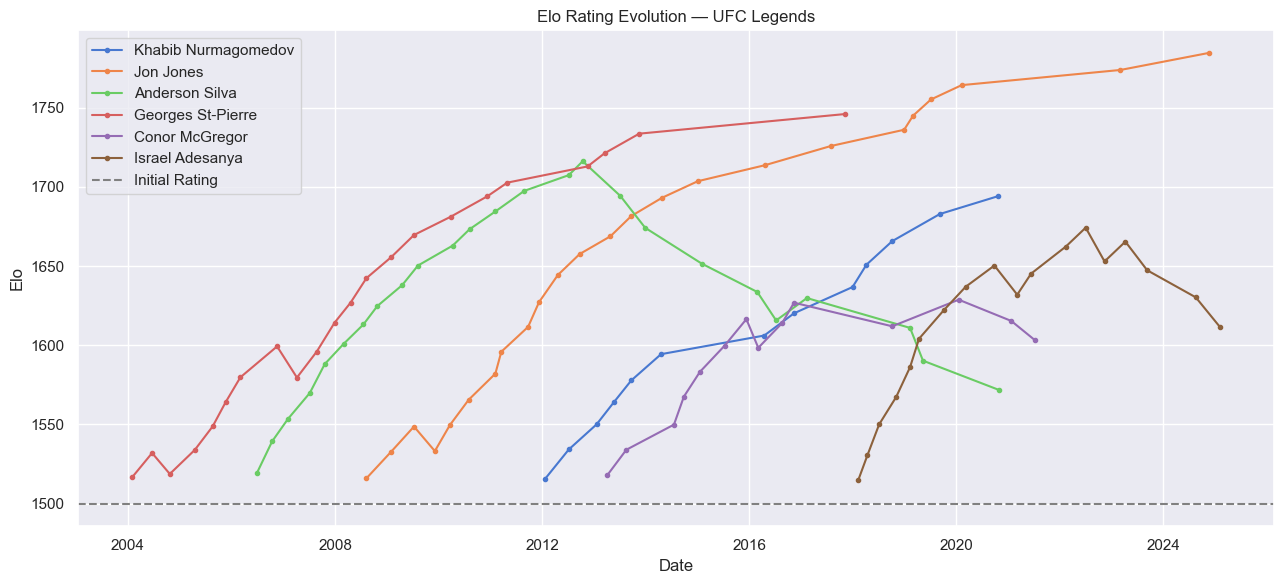

In [19]:
# Elo evolution of UFC legends
legends = ['Khabib Nurmagomedov', 'Jon Jones', 'Anderson Silva',
           'Georges St-Pierre', 'Conor McGregor', 'Israel Adesanya']
legends_in_data = [f for f in legends if f in elo_history['Fighter'].values]

if legends_in_data:
    plt.figure(figsize=(13, 6))
    for fighter in legends_in_data:
        fh = elo_history[elo_history['Fighter'] == fighter].sort_values('date')
        plt.plot(fh['date'], fh['Elo'], marker='o', markersize=3, label=fighter)
    plt.axhline(1500, linestyle='--', color='gray', label='Initial Rating')
    plt.title('Elo Rating Evolution — UFC Legends')
    plt.xlabel('Date')
    plt.ylabel('Elo')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Legend fighters not found in the dataset.')

In [20]:
# ─── 4. Comparison of the 3 ranking methods ─────────────────────────
from scipy.stats import spearmanr, kendalltau

print('=== CONVERGENCE OF THE 3 RANKING METHODS ===\n')

# Build global weighted and Elo rankings (top fighters with >= MIN_FIGHTS)
w_all = rank_by_weights(fighter_stats, WEIGHTS, None, MIN_FIGHTS_RANKING)
elo_all = elo_ranking(elo_final)

# Merge the rankings on fighter name
comp = (w_all[['Fighter', 'Rank']].rename(columns={'Rank': 'Rank_Weighted'})
        .merge(elo_all[['Fighter', 'Rank']].rename(columns={'Rank': 'Rank_Elo'}),
               on='Fighter', how='inner'))

n = len(comp)
print(f'Compared fighters (>= {MIN_FIGHTS_RANKING} fights): {n}\n')

pairs = [
    ('Weighted', 'Elo', 'Rank_Weighted', 'Rank_Elo'),
]

print(f'{"Pair":30s}  {"Spearman rho":>12s}  {"Kendall tau":>12s}  {"Interpretation"}')
print('-' * 85)
for name, name2, col1, col2 in pairs:
    rho, p_s = spearmanr(comp[col1], comp[col2])
    tau, p_k = kendalltau(comp[col1], comp[col2])
    if rho > 0.7:
        interp = 'Strong convergence'
    elif rho > 0.4:
        interp = 'Moderate convergence'
    else:
        interp = 'Weak convergence'
    print(f'{name} vs {name2:20s}  {rho:>+12.3f}  {tau:>+12.3f}  {interp}')

# Top divergences
comp['delta'] = abs(comp['Rank_Weighted'] - comp['Rank_Elo'])
comp_sorted = comp.sort_values('delta', ascending=False)

print(f'\n--- Top 10 Largest Divergences: Weighted vs Elo ---')
print(comp_sorted[['Fighter', 'Rank_Weighted', 'Rank_Elo', 'delta']].head(10).to_string(index=False))

print(f'\n--- Top 10 Fighters Where Both Methods Converge ---')
print(comp_sorted[['Fighter', 'Rank_Weighted', 'Rank_Elo', 'delta']].tail(10).to_string(index=False))

=== CONVERGENCE OF THE 3 RANKING METHODS ===

Compared fighters (>= 5 fights): 1250

Pair                            Spearman rho   Kendall tau  Interpretation
-------------------------------------------------------------------------------------
Weighted vs Elo                         +0.689        +0.495  Moderate convergence

--- Top 10 Largest Divergences: Weighted vs Elo ---
              Fighter  Rank_Weighted  Rank_Elo  delta
     Anthony Hamilton            431      2609   2178
        Jordan Wright            468      2574   2106
Gadzhimurad Antigulov             77      2161   2084
   Dalcha Lungiambula            540      2573   2033
           Andrea Lee            601      2622   2021
         Jamie Varner            407      2415   2008
    Charlie Brenneman            504      2466   1962
       Daniel Lacerda            659      2610   1951
  Mara Romero Borella            704      2640   1936
       Hector Lombard            725      2655   1930

--- Top 10 Fighters Whe

---
## End of Pipeline

To re-run the pipeline on new data, execute this notebook again. Only fights after the last run will be scraped and integrated.

To modify the ranking weights, edit the `WEIGHTS` dict in Section 0.